# Working with VACs: BOSS-MINESweeper and the Outer Halo

In this example, we will explore how to work with one of SDSS-V's many [Value Added Catalogs (VACs)](https://www.sdss.org/dr19/data_access/value-added-catalogs/): [BOSS-MINESweeper](https://www.sdss.org/dr19/data_access/value-added-catalogs/?vac_id=10007). The below example is best run on [SciServer](https://www.sciserver.org), where the instructions in this repository describe how to setup an account, and container with the appropriate environment.

## Package Setup

Below we will import the standard Python and astronomy related packages to run this tutorial.

In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

from astropy.table import Table

from scipy.stats import binned_statistic_2d

%matplotlib inline

plt.rcParams.update({'figure.facecolor': 'white',
                      'savefig.facecolor': 'white',
                      'font.size': 24,
                      'xtick.labelsize': 24,
                      'ytick.labelsize': 24,
                      'errorbar.capsize': 2})

For working with SDSS data, we will also include two SDSS-centric packages: [`sdss_semaphore`](https://www.sdss.org/dr19/software/packages/semaphore) and [`sdss_access`](https://www.sdss.org/dr19/software/packages/sdss-access/). `sdss_semaphore` is used to interpret the [SDSS-V Targeting Flags](https://www.sdss.org/dr19/targeting/flags), so we can access targeting information for the various sources. `sdss_access` is a convenient tool for navigating both the local and remote file system paths from the Science Archive Server (SAS). It is especially helpful on SciServer, as the SAS has been copied here directly, meaning `sdss_access` can be used to construct paths and open relevant files.

In [2]:
from sdss_semaphore.targeting import TargetingFlags
import sdss_access

## Loading Files

For this example, we are interested in the results the VAC BOSS-MINESweeper. This VAC provides stellar parameters, metallicities, alpha abundances and various kinematic parameters for distance halo stars with BOSS spectra.

In the below code, we will first setup the path object. This allows us to specify the SDSS data release we are interested in, which in this case is DR19. Second, we will use that object to get the full path to a file we are interested in. In this case we are interested in one VAC file.

In [3]:
sdss_path = sdss_access.path.Path(release='dr19', verbose=True)
minesweep_file = sdss_path.full('minesweeper', vers='v1.0.0')
minesweep = Table.read(minesweep_file, hdu=1)

It is important to note that all SDSS-V files have associated [data models](https://data.sdss.org/datamodel/). These should be referenced to understand the content of the files.

## Plotting Results

Each VAC is a specialized processing of the SDSS-V data. The associated papers should be referenced to better understand these data. Below, we will attempt to recreate a few plots from the [BOSS-MINESweeper paper](https://iopscience.iop.org/article/10.3847/1538-4357/ae448a/pdf).

First, let's examine a Kiel diagram for the clean dataset.

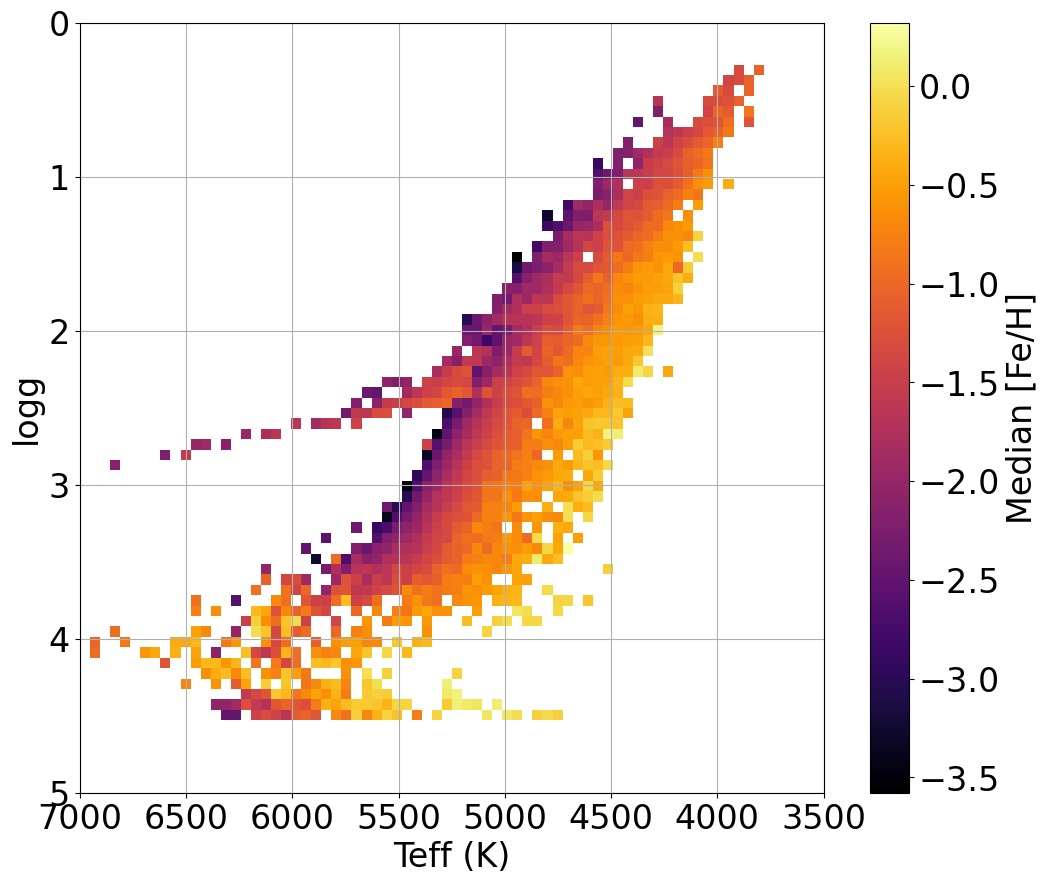

In [4]:
clean = minesweep['FLAG'] == 0

teff_bins = np.linspace(3500, 7000, 75)
logg_bins = np.linspace(0, 5, 75)

N, _, _, _ = binned_statistic_2d(minesweep["Teff"][clean],
                                 minesweep["logg"][clean],
                                 minesweep["FeH"][clean],
                                 np.nanmedian,
                                 bins=[teff_bins, logg_bins])

plt.figure(figsize=(12, 10))
res = plt.imshow(N.T, origin='lower', aspect='auto',
                 extent=[teff_bins.min(), teff_bins.max(),
                         logg_bins.min(), logg_bins.max()],
                 cmap='inferno')
plt.colorbar(res, label='Median [Fe/H]')
plt.xlabel('Teff (K)')
plt.ylabel('logg')
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.grid()
plt.show()


We can see that the sample covers a very wide range in metallicity for the giants! Reaching very low metallicity values.

Also of interest in this VAC are the kinematic and orbital parameters provided. In Chandra et al. (2026), they used these parameters to identify stars in the Sagittarius (Sgr) stream. Below let's show the VAC stars both in and out of the stream on a plot of Galactocentric RV as a function of longitude along the Sgr stream.

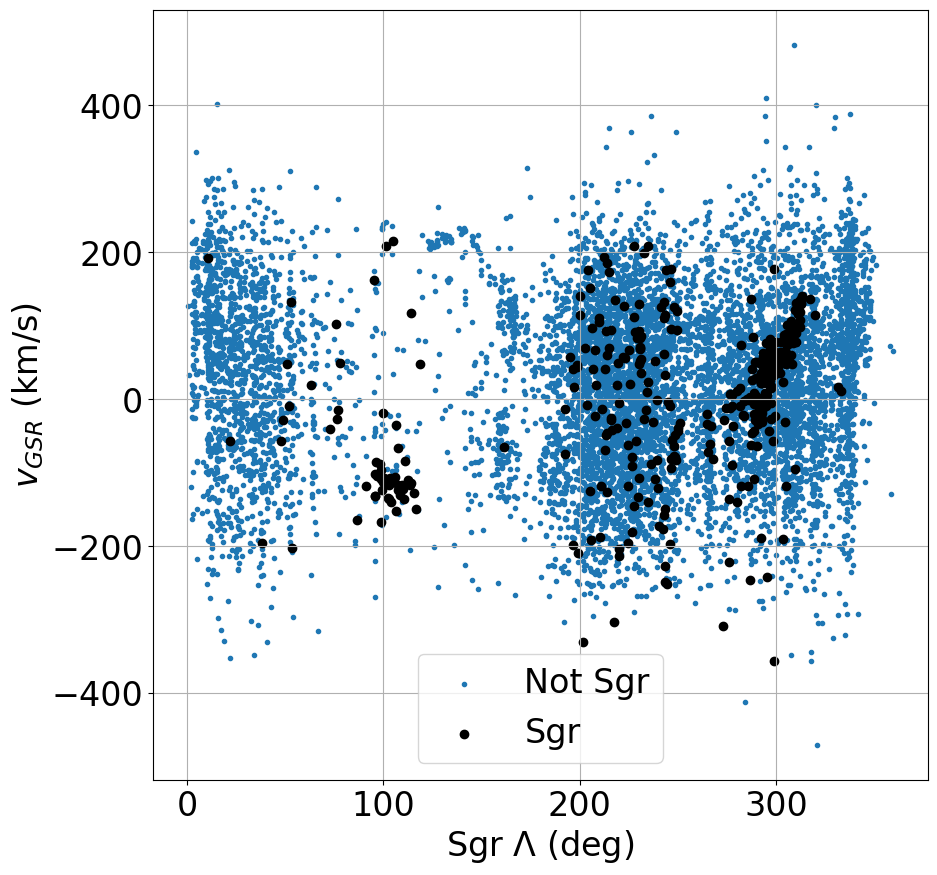

In [5]:
not_sgr = clean & ~minesweep['in_sgr_L']
sgr = clean & minesweep['in_sgr_L']

plt.figure(figsize=(10, 10))
plt.scatter(minesweep['Sgr_l'][not_sgr], minesweep['V_gsr'][not_sgr],
            marker='.', label='Not Sgr')
plt.scatter(minesweep['Sgr_l'][sgr], minesweep['V_gsr'][sgr],
            c='k', label='Sgr')
plt.xlabel(r'Sgr $\Lambda$ (deg)')
plt.ylabel(r'$v_{GSR}$ (km/s)')
plt.grid()
plt.legend()
plt.show()

We can also look at the alpha abudance vs. metallicity diagram for the Sgr stars.

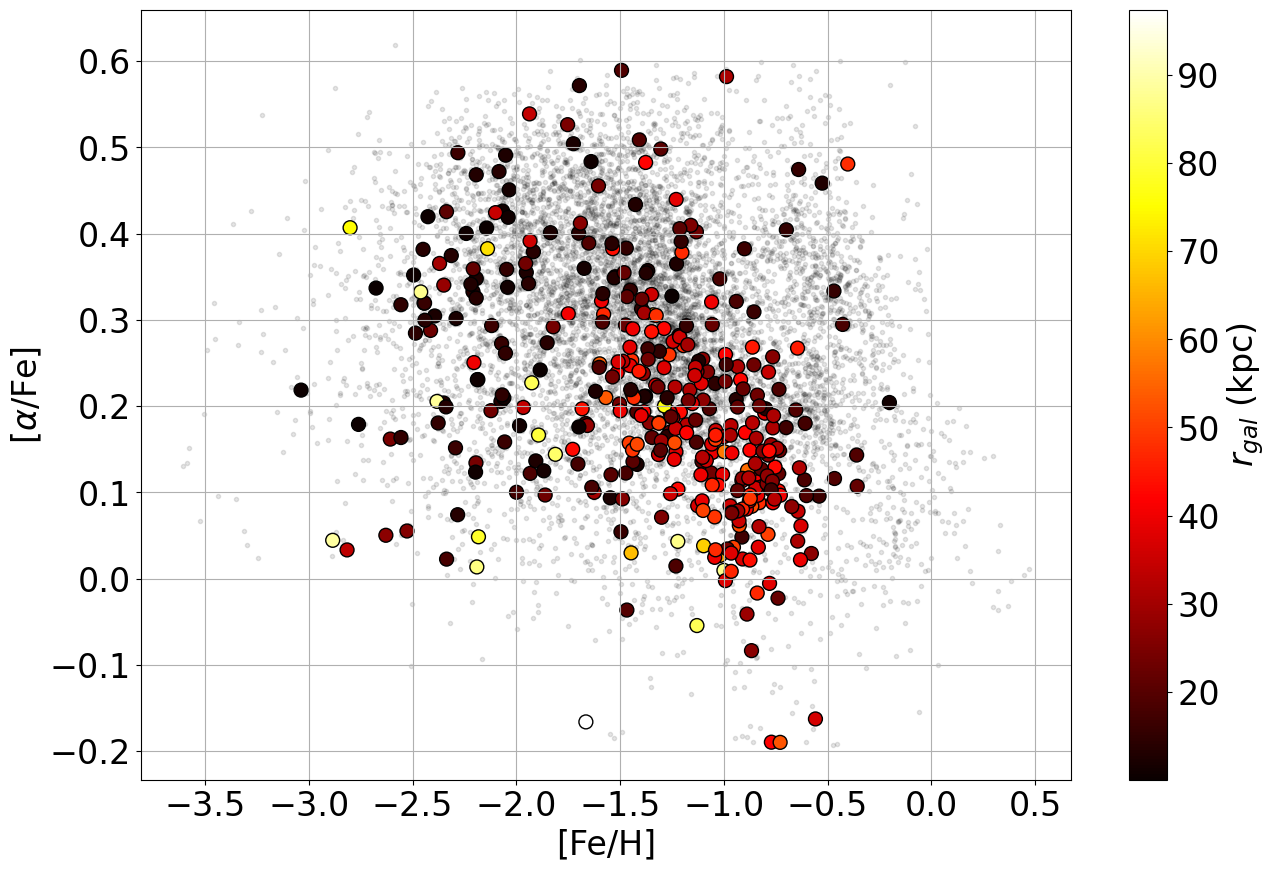

In [6]:
plt.figure(figsize=(15, 10))
plt.scatter(minesweep['FeH'][clean], minesweep['aFe'][clean],
            c='k', alpha=0.1, marker='.')
plt.scatter(minesweep['FeH'][sgr], minesweep['aFe'][sgr],
            c=minesweep['R_gal'][sgr], cmap='hot', edgecolor='k', s=100)
plt.colorbar(label=r'$r_{gal}$ (kpc)')
plt.xlabel(r'[Fe/H]')
plt.ylabel(r'[$\alpha$/Fe]')
plt.grid()
plt.show()

Here we color-coded the stars by Galactocentric distance. From this, we see a clear pattern that the more distance stars are more metal-poor, on average. Additionally, we find that for a fixed metallicity, the distance stars are more alpha poor as well! Chandra et al. (2026) note that this trend is expected if Sgr's halo was formed from mergers with smaller dwarf galaxies, as these would be the earliest stripped (and most distant) Sgr debris in our Galaxy.

Now see what other trends you can find with this dataset!